# 活笔记：TFLN 慢光色散器件
**打开即渲染**：本文本格渲染公式与文字，代码格可直接运行，运行结果（图、数值）内嵌保存在笔记里。随讨论不断生长。

学习背景：已有脉冲压缩 / SAR 基础；正在补 Level 0 第 2–3 项（色散来源、耦合模理论）。

## 0. 组织公理（2026-09-10）
本项目的所有物理量都是群折射率 $n_g$ 或其对频率的导数：

| 关心的量 | 表达式 | 说明 |
|---|---|---|
| 调制效率 | $\Delta\phi \propto n_g L$ | 行波相位调制器，$V_\pi L \propto 1/n_g$ |
| 群延迟 | $	au(\omega) = n_g L / c$ | ripple 是 $	au(\omega)$ 的抖动 |
| GVD | $eta_2 = \dfrac{dn_g}{d\omega} = \dfrac{d^2 n}{d\omega^2}$ | 色散的物理本质 |
| 色散（器件规格） | $D = \dfrac{d	au}{d\lambda} = -\dfrac{2\pi c}{\lambda^2}\,eta_2$ | 系统语言与物理语言的互译 |
| 传播损耗惩罚 | $lpha \propto n_g$（散射损耗标度） | 慢光的代价之一 |
| 可用带宽 | $\Delta\omega \cdot 	au \sim$ 常数 | 延迟-带宽积约束 |

**关键区分**：相折射率 $n$（LN ≈ 2.2）决定模式分布与布拉格条件 $\lambda_B = 2 n_{m eff}\Lambda$；群折射率 $n_g$ 决定包络速度与相互作用时间——本项目的主角。

慢光与大色散是同一物理（光子带结构的频率依赖性）的两个表现：带边附近 $n_g$ 巨大 → 慢光（调制增强）；$n_g$ 随 $\omega$ 剧变 → 大 GVD（目标功能）。

## 1. 色散的三种来源（2026-09-10）
$D = d	au/d\lambda$ 的定义唯一，区别在 $n_g(\omega)$ 从哪来：
1. **材料色散**：材料 $n(\omega)$ 的曲率。LN 在通信波段为正常色散。改不了多少。
2. **波导色散**：$n_{m eff}(\omega)$ 随约束变化。可用波导尺寸调节，量级小。
3. **光栅/结构色散**：周期结构打开光子带隙，带边 $n_g$ 剧变——**量级最大，本项目唯一重要**。啁啾把带边扫过一段波长 → 大带宽内的大 $D$。

## 2. 设计目标的一句话（2026-09-10）
> 把 $	au(\lambda)$ 拉成一条**斜率大且直**的线：斜率 = 平均色散 $D$；不平直度 = GD ripple。
> 所有设计规则（长度、啁啾率、apodization、刻蚀质量）都围绕这句话。

## 3. 均匀 Bragg 光栅的解析模型（2026-09-10）
耦合模理论（CMT），无损耗单模均匀光栅的反射系数：
$$r(\delta) = rac{-i\kappa \sinh(\gamma L)}{\gamma \cosh(\gamma L) - i\delta \sinh(\gamma L)},\qquad \gamma = \sqrt{\kappa^2 - \delta^2},\qquad \delta = 2\pi n_{m eff}\left(rac{1}{\lambda} - rac{1}{\lambda_B}ight)$$
群延迟由反射相位对频率求导：$	au = -\dfrac{drg r}{d\omega}$。
预期：带边附近 $	au$ 鼓包（慢光），鼓包斜率 = 局部大色散，鼓包抖动 = ripple 藏身之处。

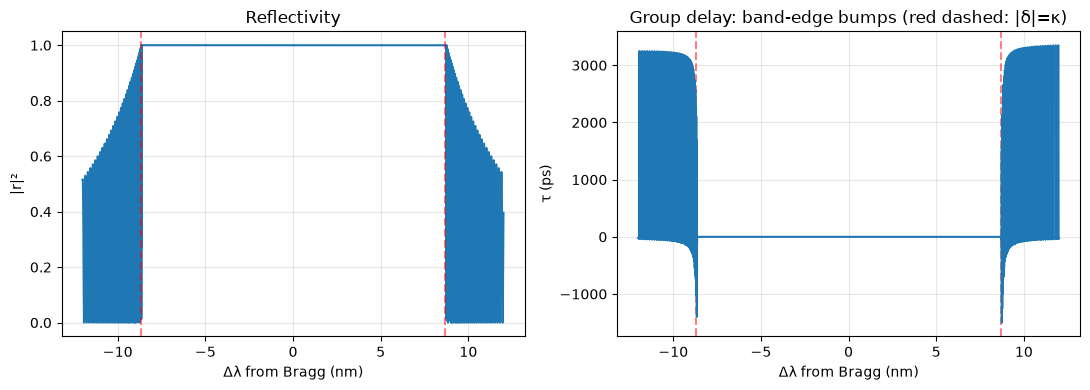

带边最大群延迟: 3351 ps


In [1]:
"""均匀 Bragg 光栅：反射谱 + 群延迟谱"""
import numpy as np
import matplotlib.pyplot as plt

n_eff, lam_b = 2.2, 1550e-9
kappa, L = 5e4, 2.5e-3        # [1/m], [m]
c = 299792458.0

# 带隙半宽 Δλ = λ_B²κ/(2π n_eff) ≈ 8.7 nm → 窗口必须盖过带边
lam = np.linspace(lam_b - 12e-9, lam_b + 12e-9, 40001)
delta = 2*np.pi*n_eff*(1.0/lam - 1.0/lam_b)
gam = np.sqrt(kappa**2 - delta**2 + 0j)
r = -1j*kappa*np.sinh(gam*L) / (gam*np.cosh(gam*L) - 1j*delta*np.sinh(gam*L))
R = np.abs(r)**2
phi = np.unwrap(np.angle(r))
tau = -np.gradient(phi, 2*np.pi*c/lam)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
dlnm = (lam - lam_b)*1e9
ax[0].plot(dlnm, R); ax[0].set(xlabel='Δλ from Bragg (nm)', ylabel='|r|²', title='Reflectivity')
edge = lam_b**2*kappa/(2*np.pi*n_eff)*1e9
for e in (-edge, edge):
    for a in ax: a.axvline(e, color='r', ls='--', alpha=.5)
ax[1].plot(dlnm, tau*1e12); ax[1].set(xlabel='Δλ from Bragg (nm)', ylabel='τ (ps)',
    title='Group delay: band-edge bumps (red dashed: |δ|=κ)')
for a in ax: a.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f'带边最大群延迟: {tau.max()*1e12:.0f} ps')

### 结果解读（2026-09-18 运行）
1. **带边鼓包确认**：带隙外 $	au pprox 3.3$ ns 且剧烈振荡；带内 $	au pprox 0$。带边位置与解析预测 $|\delta|=\kappa$ 精确吻合。
2. **振荡 = 未 apodize 光栅的本征 GD ripple**：理想无损均匀光栅两端构成等效 F-P 腔，腔模表现为等间隔振荡。**启示：ripple 不需要相位误差就会出现——apodization 的物理起点。**
3. **调试教训**：窗口要盖过带边。初版 ±2 nm 只见带内平台，τ 平坦如直线。

**待做**：线性啁啾光栅 → 把 τ(λ) 从鼓包拉成斜线，定量验证 D 与啁啾率的关系。

## Q: 待回答
- 慢光区带宽-延迟积的定量约束：$\Delta\omega\cdot	au$ 与 $\kappa$、啁啾率的关系？
- Yu 2022 (Nature) 的 1.6 ps/nm 器件：$n_g$ 多大？可用带宽多少 nm？
- 传播损耗 $\propto n_g$ 标度律在 TFLN 侧壁散射下成立吗？
- 啁啾光栅中"慢光区"是移动目标，对 ripple 意味着什么？